# Example 1

We consider the following stochastic Volterra integral equation

$$X_t = 1 + \int\limits_0^t s^2 X_s ds + \int\limits_0^t s X_s dB_s, \qquad t \in [0, 0.5),$$

so $f \equiv 1$, $k_1(s,t) = s^2$, $k_2(s,t) = s$ and $T=0.5$.

First we import the required packages and methods

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nssvie import (
    SVIE,
    GaussianProcess
)

and define the function $f$, the kernels $k_1, k_2$ and the parameters for our model:

In [26]:
def f(t):
    """f(t) = 1"""
    return 1

def kernel_1(s, t):
    """k_1(s,t) = s^2"""
    return s**2

def kernel_2(s, t):
    """k_2(s,t) = s"""
    return s

# Set the right hand side of the interval [0,T)
T = 0.5

# Set the number of intervals m
m = 32

h = T/m

times = np.arange(0, T, h)

# Set the number of approximations
n = 100

Next, we calculate the numerical solution of the given stochastic Volterra integral equation

In [27]:
# Set a seed
np.random.seed(1337)

example_1 = SVIE(f=f, kernel_1=kernel_1, kernel_2=kernel_2, T=T)

# Empty array for the approximate paths
samples_approx_solution = np.empty((n, m))

# Sample paths
for i in range(n):
    samples_approx_solution[i,:] = example_1.solve_numerical(
        m=m,
        solve_method='bpf'
    )

# Calculate mean
approx_solution = samples_approx_solution.mean(axis=0)

The exact solution is given by

$$X_t = \exp \left( \frac{t^3}{6} \int_0^t s dB_s \right) = \exp (Y_t), \qquad t \in [0, 0.5)$$

with

$$Y_t = \frac{t^3}{6} + \int_0^t s dB_s, \qquad t \in [0, 0.5).$$

We recall that a stochastic process $(Y_t)_{t\geq 0}$ with

$$Y_t = \int\limits_0^t f(s) ds + \int_0^t g(s) dB_s$$

is a [Gaussian process](https://en.wikipedia.org/wiki/Gaussian_process) with mean function 

$$m(t) = \int\limits_0^t f(s) ds$$

and covariance function

$$k(s,t) = \int_0^{\min(s,t)} g^2(u) du.$$

So, here 

$$Y_t = \frac{t^3}{6} + \int_0^t s dB_s$$

is a Gaussian process with mean function

$$m(t) = \frac{t^3}{6}$$

and covaricance function

$$k(s,t) = \int_0^{\min(s,t)} u^2 du = \frac{1}{3} \min(s,t)^3.$$

Simulating $Y_t$ of the exact solution

In [30]:
gp = GaussianProcess(
    mean=lambda t: (t**3)/6,
    cov=lambda s,t: (min(s,t)**3)/3
)
samples_y_t = np.zeros((n, m))
for i in range(n):
    samples_y_t[i,:] = gp.sample_at(times)
y_t = samples_y_t.mean(axis=0)

Plot the approximate and exact solution

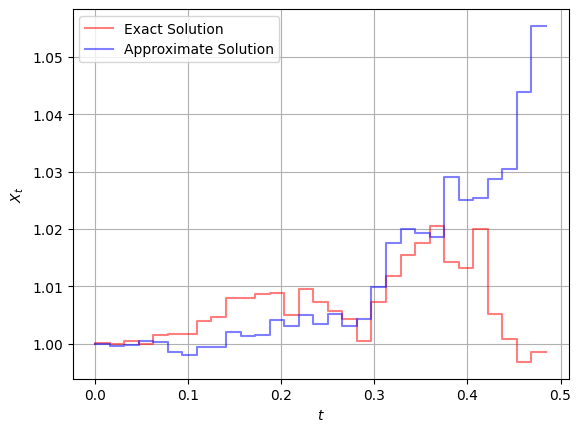

In [31]:
fig, ax = plt.subplots()
ax.step(
    times,
    np.exp(y_t),
    label='Exact Solution',
    color='red',
    alpha=0.5
)
ax.step(
    times,
    approx_solution,
    label='Approximate Solution',
    color='blue',
    alpha=0.5
)
ax.set(xlabel=r'$t$', ylabel=r'$X_t$')
ax.legend()
ax.grid()
plt.show()